In [1]:
#Simulation study of a 3 factor model 

In [2]:
#import of packages

import numpy as np
import math
import matplotlib.pyplot as plt

from scipy.linalg import sqrtm #matrix square root
from scipy.stats import gaussian_kde

print("ok")

ok


In [3]:
#parameters for the framework

#save images?
save_image=0       # 1 = yes, 0 = no

#how to deal with negative sigma^2?
deal_neg_sigma_square=1     # 1= abs , 2= max(0,)

#cholesky decomposition or matrix square root?
rho_matrix_sq_root=0     #0=cholesky (triangular matrix) , 1=square root of matrix

#initialization of the processes gamma and sigma:
init_gamma=3   #0=with zeros, 1= with mean , 2= normal, 3=with mean/2
init_sigma=0   #0=with zeros, 1= with mean , 2= normal

#scaling factor of the tuning parameters
factor_lambda=1     #scale lambda_subsam by a prefactor: 1=default tuning

print("ok")

ok


In [4]:
#definition of the statistical model

#model parameters

T=1
n=78
delta_n=T/n

#dimension
d=30
#number of systematic factors
r=3


#parameters of the included processes

#idiosyncratic noise: Z
div=1       #parameters of Z divided by div to control influence of noise: 1=default
kappa_Z=4/div
theta_Z=0.25/div
eta_Z=0.06/div

#volatility of systematic factors: sigma_square
kappa=np.array([3,4,5])
theta=np.array([0.05,0.04,0.03])
eta=np.array([0.3,0.4,0.3])
rho=np.array([-0.6,-0.4,-0.25])

#systematic factors: F
alpha=np.array([0.05,0.03,0.02])
L_L_T=np.array([[1,0.05,0.1],[0.05,1,0.15],[0.1,0.15,1]])
if rho_matrix_sq_root==0:
    L=np.linalg.cholesky(L_L_T)
elif rho_matrix_sq_root==1:
    L=sqrtm(L_L_T)
#print(L@L.T)

#log-price process: Y
beta_market_lower=0.25
beta_market_upper=1.75
beta_normal_std=0.5
beta_normal_exp=0

#L_n for subsampling of lambda_subsam
L_lambda=6 #divides n!


print("ok")

ok


In [5]:
#Monte Carlo simulation

#number of replications
number_paths=10000

#storage for observations
monte_carlo_of_eigenvalues_normed=np.zeros((number_paths, d))
monte_carlo_lambdas=np.zeros(number_paths)
normed_monte_carlo_lambdas=np.zeros(number_paths) #normed by the largest eigenvalue of the corresponding rv
rank_prv_monte_carlo=np.zeros(number_paths)

nuclear_estimation_error_rv_monte_carlo=np.zeros(number_paths)
nuclear_estimation_error_prv_monte_carlo=np.zeros(number_paths)
frobenius_estimation_error_rv_monte_carlo=np.zeros(number_paths)
frobenius_estimation_error_prv_monte_carlo=np.zeros(number_paths)
spectral_estimation_error_rv_monte_carlo=np.zeros(number_paths)
spectral_estimation_error_prv_monte_carlo=np.zeros(number_paths)

only_factors_nuclear_estimation_error_rv_monte_carlo=np.zeros(number_paths)
only_factors_nuclear_estimation_error_prv_monte_carlo=np.zeros(number_paths)
only_factors_frobenius_estimation_error_rv_monte_carlo=np.zeros(number_paths)
only_factors_frobenius_estimation_error_prv_monte_carlo=np.zeros(number_paths)
only_factors_spectral_estimation_error_rv_monte_carlo=np.zeros(number_paths)
only_factors_spectral_estimation_error_prv_monte_carlo=np.zeros(number_paths)


#simulation of paths and estimators

for j in range(number_paths):
    
    #paths 

    #included stochastic processes

    #gamma
    gamma_square_t_j=np.zeros((n+1,d))
    if init_gamma==1:
        gamma_square_t_j[0,:]=theta_Z*np.ones(d)
    elif init_gamma==2:
        gamma_square_t_j[0,:]=np.abs(np.random.normal(theta_Z, beta_normal_std/10, (1,d)))
    elif init_gamma==3:
        gamma_square_t_j[0,:]=(theta_Z/2)*np.ones(d)

    dB_tilde=np.sqrt(delta_n)*np.random.randn(n,d)

    #Z
    dB=np.sqrt(delta_n)*np.random.randn(n,d)
    delta_Z_t=np.zeros((n,d))

    #sigma-squared
    dW=np.sqrt(delta_n)*np.random.randn(n,r)
    dW_tilde=np.sqrt(delta_n)*np.random.randn(n,r)
    sigma_square=np.zeros((n+1,r))
    if init_sigma==1:
        sigma_square[0,:]=theta
    elif init_sigma==2:
        sigma_square[0,:]=np.abs(theta+np.random.normal(0, beta_normal_std/100, (1,r))) 

    #F
    delta_F=np.zeros((n,r))

    #Y
    beta=np.zeros((d,r))
    beta[:,0]=np.random.uniform(beta_market_lower, beta_market_upper, d)
    beta[:,1:]=np.random.normal(beta_normal_exp, beta_normal_std, (d,(r-1)))

    delta_Y=np.zeros((n,d))
    
    #c_t
    integrated_c_t=np.zeros((d,d))
    only_factors_integrated_c_t=np.zeros((d,d))


    #simulation of the paths based on the Euler-Maruyama scheme
    for i in range(n):
        gamma_square_t_j[i+1,:]=(gamma_square_t_j[i,:]+kappa_Z*(theta_Z*np.ones(d)-gamma_square_t_j[i,:])*delta_n
                            + eta_Z*np.sqrt(gamma_square_t_j[i,:])*dB_tilde[i,:])

        delta_Z_t[i,:]=np.sqrt(gamma_square_t_j[i,:])*dB[i,:]

        
        #attention: here might occur the error 'RuntimeWarning: invalid value encountered in sqrt' if sigma_square < 0
        #solution: apply max(,0) or abs to prevent this 
        if deal_neg_sigma_square==2: 
            #solution max(,0)
            sigma_square[i+1,:]=np.maximum((sigma_square[i,:]+kappa*(theta-sigma_square[i,:])*delta_n
                                 +eta*np.sqrt(sigma_square[i,:])*(rho*dW[i,:]+np.sqrt(np.ones(r)-np.square(rho))*dW_tilde[i,:])), 
                                np.zeros(r))
        elif deal_neg_sigma_square==1:
            #solution abs
            sigma_square[i+1,:]=np.abs((sigma_square[i,:]+kappa*(theta-sigma_square[i,:])*delta_n
                                 +eta*np.sqrt(sigma_square[i,:])*(rho*dW[i,:]+np.sqrt(np.ones(r)-np.square(rho))*dW_tilde[i,:])))
        else:
            #error might occur
            sigma_square[i+1,:]=(sigma_square[i,:]+kappa*(theta-sigma_square[i,:])*delta_n
                                 +eta*np.sqrt(sigma_square[i,:])*(rho*dW[i,:]+np.sqrt(np.ones(r)-np.square(rho))*dW_tilde[i,:]))

            
            
        delta_F[i,:]=delta_n*alpha+(np.diag(np.sqrt(sigma_square[i,:]))@L@(dW[i,:].reshape(r,1))).T

        delta_Y[i,:]=(beta@(delta_F[i,:].reshape(r,1))).T+delta_Z_t[i,:]
        
        
        #estimation of the integrated variance (= quadratic variation)
        #index i+1 is used to reduce the influence of the initializations of the processes sigma_square and gamma_square
        integrated_c_t+=delta_n*(beta@np.diag(np.sqrt(sigma_square[i+1,:]))@L_L_T@np.diag(np.sqrt(sigma_square[i+1,:]))@(beta.T)
                                 +np.diag(gamma_square_t_j[i+1,:]))
        only_factors_integrated_c_t+=delta_n*(beta@np.diag(np.sqrt(sigma_square[i+1,:]))@L_L_T@np.diag(np.sqrt(sigma_square[i+1,:]))@(beta.T))



    #calculation of the realized variance
    sigma_hat_n_rv=np.zeros((d,d))
    for i in range(n):
        sigma_hat_n_rv+= (delta_Y[i,:].reshape(1,d).T) @ delta_Y[i,:].reshape(1,d)    

    #eigenvalues of the rv
    eigenvalues_rv=(np.linalg.eigvalsh(sigma_hat_n_rv))[::-1]    #decreasing order now
    eigenvalues_rv_normed=eigenvalues_rv/np.sum(eigenvalues_rv)
    monte_carlo_of_eigenvalues_normed[j,:]=eigenvalues_rv_normed

    #subsampling procedure for the selection of the tuning parameter lambda
    lambdas=np.zeros(L_lambda)
    for l in range(L_lambda):
        
        delta_Y_subsample=delta_Y[np.arange(l,n,L_lambda),:]
        subsamp_sigma_hat_n_rv=np.zeros((d,d))
        
        for k in range(delta_Y_subsample.shape[0]):
            subsamp_sigma_hat_n_rv+= (L_lambda)*(delta_Y_subsample[k,:].reshape(1,d).T) @ (delta_Y_subsample[k,:].reshape(1,d)) 
            
        lambdas[l]=(2/np.sqrt(L_lambda))*np.linalg.norm((subsamp_sigma_hat_n_rv - sigma_hat_n_rv), ord=2) #spectral norm = order 2
       
    lambda_final=np.mean(lambdas)*factor_lambda #attention, here factor from cell 'parameters for the framework' 
    monte_carlo_lambdas[j]=lambda_final
    normed_monte_carlo_lambdas[j]=lambda_final/eigenvalues_rv[0]
    
    #calculation of the PRV estimator (Theorem 3.6 in the thesis)
    sigma_hat_n_lambda_prv=np.zeros((d,d))
    Sigma_ascending, U = np.linalg.eigh(sigma_hat_n_rv)
    rank_prv_monte_carlo[j]=d 
    #if all shrinked eigenvalues are positive, the else below is never reached, so need rank d then
    
    for z in range(d):
        if Sigma_ascending[d-z-1]>(lambda_final/2):
            sigma_hat_n_lambda_prv+=(Sigma_ascending[d-z-1]-(lambda_final/2))* ((U[:,d-z-1].reshape(d,1)) @ (U[:,d-z-1].reshape(d,1).T))
            #attention: since the eigenvalues in Sigma_ascending are increasing, the index is d-z-1 instead of z!
        else:
            #as the rank is increasing, all other eigenvalues are also samller than lambda_final/2
            rank_prv_monte_carlo[j]=z
            break 
    
    #estimation errors
    
    nuclear_estimation_error_rv_monte_carlo[j]=np.linalg.norm(sigma_hat_n_rv-integrated_c_t,ord='nuc')
    nuclear_estimation_error_prv_monte_carlo[j]=np.linalg.norm(sigma_hat_n_lambda_prv-integrated_c_t,ord='nuc')
    frobenius_estimation_error_rv_monte_carlo[j]=np.linalg.norm(sigma_hat_n_rv-integrated_c_t,ord='fro')
    frobenius_estimation_error_prv_monte_carlo[j]=np.linalg.norm(sigma_hat_n_lambda_prv-integrated_c_t,ord='fro')
    spectral_estimation_error_rv_monte_carlo[j]=np.linalg.norm(sigma_hat_n_rv-integrated_c_t,ord=2)
    spectral_estimation_error_prv_monte_carlo[j]=np.linalg.norm(sigma_hat_n_lambda_prv-integrated_c_t,ord=2)

    only_factors_nuclear_estimation_error_rv_monte_carlo[j]=np.linalg.norm(sigma_hat_n_rv-only_factors_integrated_c_t,ord='nuc')
    only_factors_nuclear_estimation_error_prv_monte_carlo[j]=np.linalg.norm(sigma_hat_n_lambda_prv-only_factors_integrated_c_t,ord='nuc')
    only_factors_frobenius_estimation_error_rv_monte_carlo[j]=np.linalg.norm(sigma_hat_n_rv-only_factors_integrated_c_t,ord='fro')
    only_factors_frobenius_estimation_error_prv_monte_carlo[j]=np.linalg.norm(sigma_hat_n_lambda_prv-only_factors_integrated_c_t,ord='fro')
    only_factors_spectral_estimation_error_rv_monte_carlo[j]=np.linalg.norm(sigma_hat_n_rv-only_factors_integrated_c_t,ord=2)
    only_factors_spectral_estimation_error_prv_monte_carlo[j]=np.linalg.norm(sigma_hat_n_lambda_prv-only_factors_integrated_c_t,ord=2)

    
    if j% (number_paths/10)==0:
        print(f"ok,j={j} is finished.")
    
print("ok")    

ok,j=0 is finished.
ok,j=1000 is finished.
ok,j=2000 is finished.
ok,j=3000 is finished.
ok,j=4000 is finished.
ok,j=5000 is finished.
ok,j=6000 is finished.
ok,j=7000 is finished.
ok,j=8000 is finished.
ok,j=9000 is finished.
ok


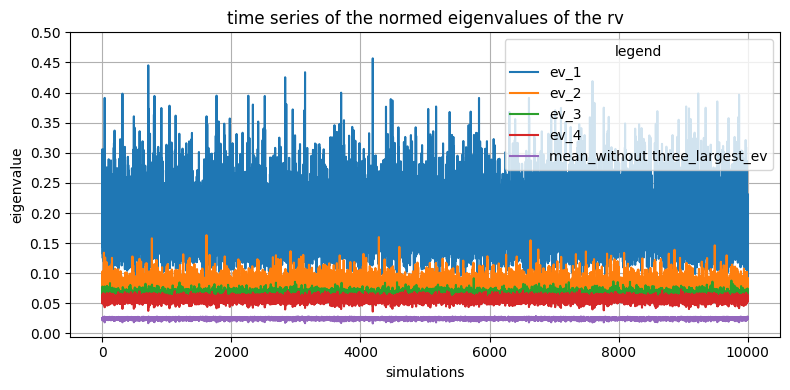

ok


In [6]:
#plot eigenvalues-normed
normed_eigenvalue_mean_without_three_largest=np.mean(monte_carlo_of_eigenvalues_normed[:, 3:], axis=1)

plt.figure(figsize=(8, 4))
plt.plot(monte_carlo_of_eigenvalues_normed[:, 0], label='ev_1')
plt.plot(monte_carlo_of_eigenvalues_normed[:, 1], label='ev_2')
plt.plot(monte_carlo_of_eigenvalues_normed[:, 2], label='ev_3')
plt.plot(monte_carlo_of_eigenvalues_normed[:, 3], label='ev_4')
plt.plot(normed_eigenvalue_mean_without_three_largest, label='mean_without three_largest_ev')

plt.yticks(np.arange(0,0.55,0.05))

plt.title('time series of the normed eigenvalues of the rv')
plt.xlabel('simulations')
plt.ylabel('eigenvalue')
plt.legend(loc='upper right', title='legend')
plt.grid(True)
plt.tight_layout()

if save_image==1:
    plt.savefig("plot_1_ev_paths_rv___n_78___abs_in_sigma___zero_start_values_sigma____half_mean_gamma___Cholesky_0.png", dpi=300, bbox_inches="tight") 
    #high resolution dpi, cut of edge bbox

plt.show()
plt.close()

print("ok")

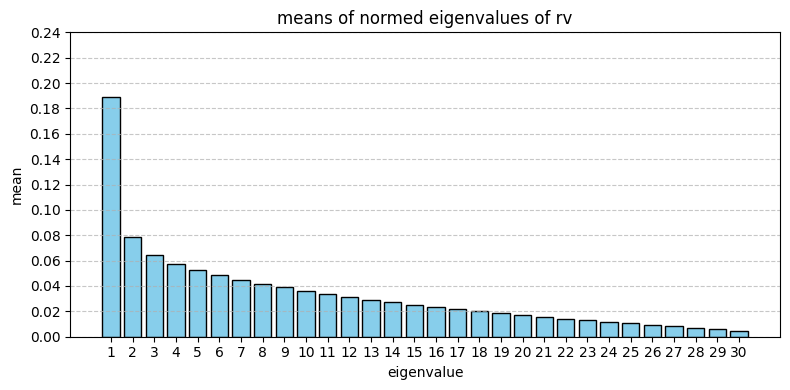

ok


In [7]:
#plot of means

# Compute mean of each column
normed_eigenvalue_means = np.mean(monte_carlo_of_eigenvalues_normed, axis=0)

cols= np.arange(1, d+1)
#plot
plt.figure(figsize=(8, 4))
plt.bar(cols, normed_eigenvalue_means, color='skyblue', edgecolor='black')
plt.xlabel('eigenvalue')
plt.ylabel('mean')
plt.title('means of normed eigenvalues of rv')
plt.xticks(cols) #ticks at the columns
plt.yticks(np.arange(0,0.25,0.02))

plt.grid(axis='y', linestyle='--', alpha=0.7) #only horizontal lines 
plt.tight_layout()

if save_image==1:
    plt.savefig("plot_2_means_ev_rv___n_78___abs_in_sigma___zero_start_values_sigma____half_mean_gamma___Cholesky_0.png", dpi=300, bbox_inches="tight") 
    #high resolution dpi, cut of edge bbox

plt.show()
plt.close()

print("ok")

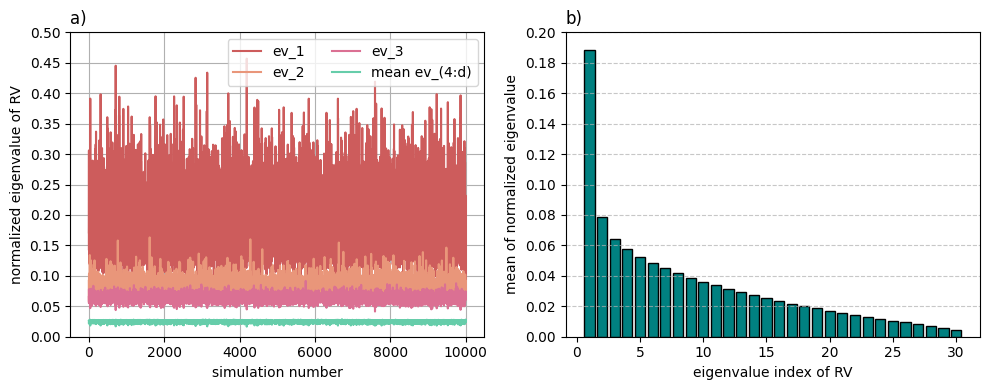

Both parts align with Figure 1 from Christensen et al. (2013), the only visible deviation being a slightly smaller normalized ev_1 (mean of 19 rather than 19.5).
ok


In [19]:
#plot for thesis

#normed eigenvalues of the rv and their means over time


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,4)) #(10,4) is good  , (8,4) is ok

#a) normed ev time series
eigenvalue_mean_rv_without_three_largest=np.mean(monte_carlo_of_eigenvalues_normed[:, 3:], axis=1)

ax1.plot(monte_carlo_of_eigenvalues_normed[:, 0], label='ev_1', color="indianred")
ax1.plot(monte_carlo_of_eigenvalues_normed[:, 1], label='ev_2', color="darksalmon")
ax1.plot(monte_carlo_of_eigenvalues_normed[:, 2], label='ev_3', color="palevioletred") #darkkhaki
#ax1.plot(monte_carlo_of_eigenvalues_normed[:, 3], label='ev_4', color="olive")
ax1.plot(eigenvalue_mean_rv_without_three_largest, label='mean ev_(4:d)', color="mediumaquamarine")


ax1.tick_params(axis='y')
ax1.set_xlabel("simulation number")
ax1.set_ylabel("normalized eigenvalue of RV")
ax1.set_title("a) ", loc="left")
ax1.legend(ncol=2, loc="upper right")
ax1.grid(True)
#ax1.tick_params(axis='x',rotation=0)
ax1.set_ylim((0,0.5))
ax1.set_yticks(np.arange(0,0.55,0.05))


#b) means across the replications

# Compute mean of each column
eigenvalue_means = np.mean(monte_carlo_of_eigenvalues_normed, axis=0)

cols= np.arange(1, d+1)

ax2.bar(cols, eigenvalue_means, width=0.8,color='teal', edgecolor='black') #color='mediumaquamarine'


ax2.set_xlabel("eigenvalue index of RV")
ax2.set_ylabel("mean of normalized eigenvalue")
ax2.tick_params(axis='y')
ax2.tick_params(axis='x')
ax2.set_yticks(np.arange(0,0.22,0.02))


ax2.set_title("b)", loc="left")
ax2.grid(axis='y', linestyle='--', alpha=0.7) #only horizontal lines

plt.tight_layout()
plt.show()

fig.savefig("three_factors_eigenvalues_rv.png", dpi=300, bbox_inches="tight")
        #high resolution dpi, cut of edge bbox
plt.close()

print("Both parts align with Figure 1 from Christensen et al. (2013), the only visible deviation being a slightly smaller normalized ev_1 (mean of 19 rather than 19.5).")

print("ok")

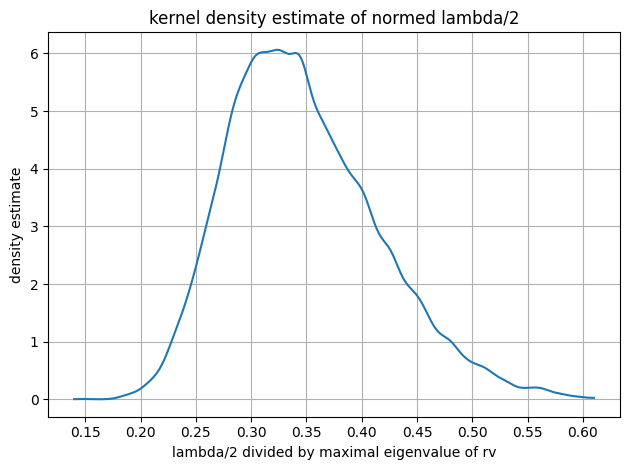

ok


In [9]:
#kernel density estimation of lambda

kde = gaussian_kde(normed_monte_carlo_lambdas/2, bw_method=0.1) #bw_method controls smoothing
x = np.linspace(0.14, 0.61, 1000)
plt.plot(x, kde(x))
plt.title("kernel density estimate of normed lambda/2")
plt.xlabel('lambda/2 divided by maximal eigenvalue of rv')
plt.ylabel('density estimate')

plt.xticks(np.arange(0.15,0.65,0.05))

plt.grid(True)
plt.tight_layout()

if save_image==1:
    plt.savefig("plot_3_lambda_kde___n_78___L_6___factor_1___abs_in_sigma___zero_start_values_sigma____half_mean_gamma___Cholesky_0.png", dpi=300, bbox_inches="tight") 
    #high resolution dpi, cut of edge bbox

plt.show()
plt.close()

print("ok")


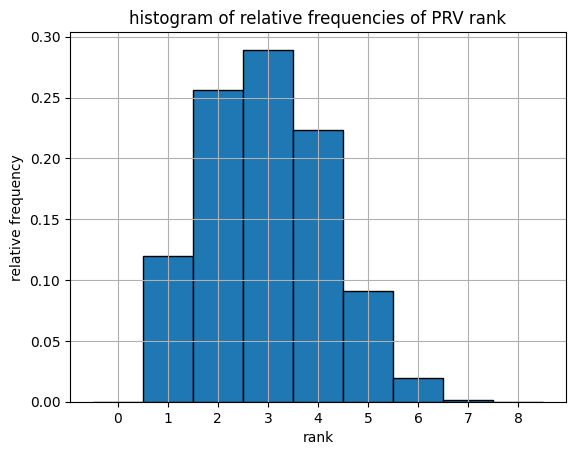

mean of PRV ranks=  2.9724
ok


In [10]:
#rank of prv

bins_def = np.arange(0, np.max(rank_prv_monte_carlo) + 3) - 0.5                    #bin edges:-0.5,0.5,...,max_rank+2-0.5
plt.hist(rank_prv_monte_carlo, bins=bins_def, density=True, edgecolor='black')     #density for relative
plt.xticks(np.arange(0,np.max(rank_prv_monte_carlo) + 2))
plt.title("histogram of relative frequencies of PRV rank")
plt.xlabel("rank")
plt.ylabel("relative frequency")
plt.grid(True)

if save_image==1:
    plt.savefig("plot_4_rank_prv___n_78___L_6___factor_1___abs_in_sigma___zero_start_values_sigma____half_mean_gamma___Cholesky_0.png", dpi=300, bbox_inches="tight") 
    #high resolution dpi, cut of edge bbox

plt.show()
plt.close()

print("mean of PRV ranks= ", np.mean(rank_prv_monte_carlo))

print("ok")


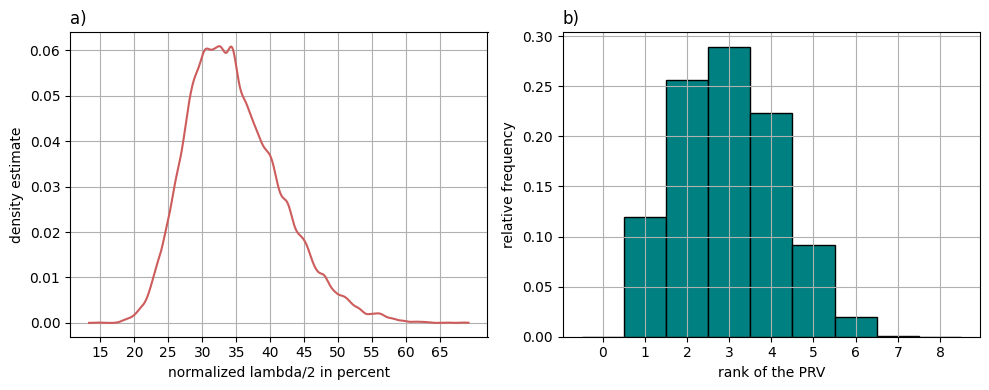

mean of normed lambda/2 in percent=  34.77088012039245
mean of lambda/2 =  0.5170768084222472
mean of PRV ranks=  2.9724
minimum of PRV ranks=  1.0
maximum of PRV ranks=  7.0
ok


In [11]:
#plot for thesis


#kernel density estimate of tuning parameter and histogram of PRV ranks
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,4)) #(10,4) is good  , (8,4) is ok

#a) kde

smoothing=0.08
kde = gaussian_kde(100*normed_monte_carlo_lambdas/2, bw_method=smoothing) #bw_method controls smoothing
x = np.linspace(np.min(100*normed_monte_carlo_lambdas/2)*0.9, np.max(100*normed_monte_carlo_lambdas/2)*1.01, 1000)
ax1.plot(x, kde(x), color="indianred")
ax1.set_xlabel("normalized lambda/2 in percent")
ax1.set_ylabel("density estimate")
ax1.set_title("a)", loc="left")
ax1.grid(True)
ax1.set_xticks(np.arange(15,70,5))


#b) histogram

#histogram of prv ranks
ranks=rank_prv_monte_carlo
bins_def = np.arange(np.min(ranks)-1, np.max(ranks) + 3) - 0.5      #bin edges:-0.5,0.5,...,max_rank+2-0.5
ax2.hist(ranks, bins=bins_def, density=True, edgecolor='black', color='teal', label="rank of PRV")  #density for relative

ax2.tick_params(axis='x')
ax2.set_xticks(np.arange(np.min(ranks) -1 ,np.max(ranks) + 2))

ax2.set_xlabel("rank of the PRV")
ax2.set_ylabel("relative frequency")
ax2.set_title("b)", loc="left")
ax2.grid(True)

plt.tight_layout()
plt.show()

fig.savefig("three_factors_kde_lambda_prv_ranks_hist.png", dpi=300, bbox_inches="tight")
        #high resolution dpi, cut of edge bbox
plt.close()

print("mean of normed lambda/2 in percent= ", np.mean(100*normed_monte_carlo_lambdas/2))
print("mean of lambda/2 = ", np.mean(monte_carlo_lambdas/2))
print("mean of PRV ranks= ", np.mean(rank_prv_monte_carlo))
print("minimum of PRV ranks= ", np.min(rank_prv_monte_carlo))
print("maximum of PRV ranks= ", np.max(rank_prv_monte_carlo))

print("ok")

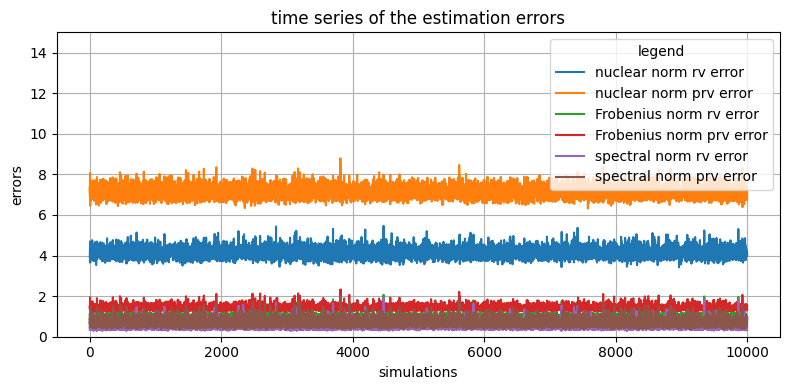

ok


In [12]:
#plot estimation errors

plt.figure(figsize=(8, 4))
plt.plot(nuclear_estimation_error_rv_monte_carlo, label='nuclear norm rv error')
plt.plot(nuclear_estimation_error_prv_monte_carlo, label='nuclear norm prv error')
plt.plot(frobenius_estimation_error_rv_monte_carlo, label='Frobenius norm rv error')
plt.plot(frobenius_estimation_error_prv_monte_carlo, label='Frobenius norm prv error')
plt.plot(spectral_estimation_error_rv_monte_carlo, label='spectral norm rv error')
plt.plot(spectral_estimation_error_prv_monte_carlo, label='spectral norm prv error')


plt.title('time series of the estimation errors')
plt.xlabel('simulations')
plt.ylabel('errors')
plt.ylim(0,15)
plt.legend(loc='upper right', title='legend')
plt.grid(True)
plt.tight_layout()

#if save_image==1:
    #plt.savefig("plot_est_errors___abs_in_sigma___zero_start_values_sigma____half_mean_gamma___Cholesky_0.png", dpi=300, bbox_inches="tight") 
    #high resolution dpi, cut of edge bbox

plt.show()
plt.close()

print("ok")


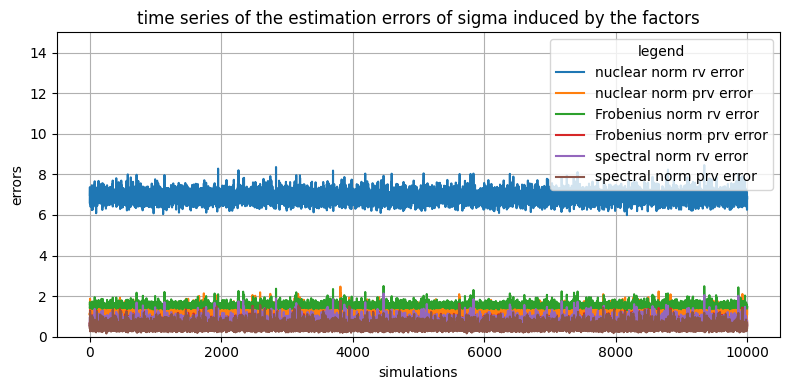

ok


In [13]:
#plot estimation errors for sigma induced by factors

plt.figure(figsize=(8, 4))

plt.plot(only_factors_nuclear_estimation_error_rv_monte_carlo, label='nuclear norm rv error')
plt.plot(only_factors_nuclear_estimation_error_prv_monte_carlo, label='nuclear norm prv error')
plt.plot(only_factors_frobenius_estimation_error_rv_monte_carlo, label='Frobenius norm rv error')
plt.plot(only_factors_frobenius_estimation_error_prv_monte_carlo, label='Frobenius norm prv error')
plt.plot(only_factors_spectral_estimation_error_rv_monte_carlo, label='spectral norm rv error')
plt.plot(only_factors_spectral_estimation_error_prv_monte_carlo, label='spectral norm prv error')

plt.title('time series of the estimation errors of sigma induced by the factors')
plt.xlabel('simulations')
plt.ylabel('errors')
plt.ylim(0,15)
plt.legend(loc='upper right', title='legend')
plt.grid(True)
plt.tight_layout()

#if save_image==1:
    #plt.savefig("plot_est_errors_only_factors___abs_in_sigma___zero_start_values_sigma____half_mean_gamma___Cholesky_0.png", dpi=300, bbox_inches="tight") 
    #high resolution dpi, cut of edge bbox

plt.show()
plt.close()

print("ok")

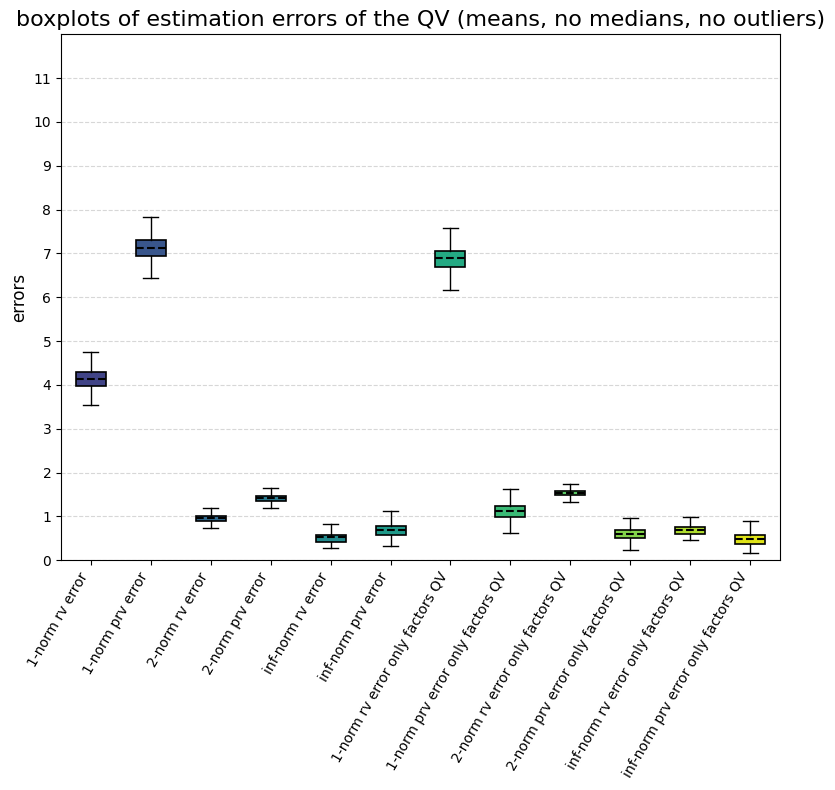

ok


In [14]:
#boxplots of the errors

data=[nuclear_estimation_error_rv_monte_carlo, nuclear_estimation_error_prv_monte_carlo,
      frobenius_estimation_error_rv_monte_carlo, frobenius_estimation_error_prv_monte_carlo,
      spectral_estimation_error_rv_monte_carlo, spectral_estimation_error_prv_monte_carlo,
      only_factors_nuclear_estimation_error_rv_monte_carlo, only_factors_nuclear_estimation_error_prv_monte_carlo,
      only_factors_frobenius_estimation_error_rv_monte_carlo, only_factors_frobenius_estimation_error_prv_monte_carlo,
      only_factors_spectral_estimation_error_rv_monte_carlo, only_factors_spectral_estimation_error_prv_monte_carlo]

labels=["1-norm rv error", "1-norm prv error",
        "2-norm rv error", "2-norm prv error",
        "inf-norm rv error", "inf-norm prv error",
        "1-norm rv error only factors QV", "1-norm prv error only factors QV",
        "2-norm rv error only factors QV", "2-norm prv error only factors QV",
        "inf-norm rv error only factors QV", "inf-norm prv error only factors QV"]

colors = plt.cm.viridis(np.linspace(0.2, 0.95, len(data))) # len(data) evenly spaced numbers

plt.figure(figsize=(8, 8))

# create boxplot
box = plt.boxplot(
    data,
    patch_artist=True, #colors for boxes  
    notch=False, #no notches
    showmeans=True, #means
    meanline=True, #as lines
    showfliers=False #no outliers
)

#apply colors
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_edgecolor('black')
    patch.set_linewidth(1.2)

#means
for mean in box['means']:
    mean.set(color='black', linewidth=1.5)

#no medians    
for median in box['medians']:
    median.set_visible(False)

# x-axis
plt.xticks(
    ticks=range(1, len(data)+1),
    labels=labels,
    rotation=60,
    ha='right' #labels to the right of tick
)

plt.yticks(np.arange(0,12,1))

plt.grid(axis='y', linestyle='--', alpha=0.5) #alpha for transparency
plt.ylabel("errors", fontsize=12)
plt.ylim(0,12)
plt.title("boxplots of estimation errors of the QV (means, no medians, no outliers)", fontsize=16)

plt.tight_layout()
if save_image==1:
    plt.savefig("boxplot_est_errors___n_78___abs_in_sigma___zero_start_values_sigma____half_mean_gamma___Cholesky_0.png", dpi=300, bbox_inches="tight") 
    #high resolution dpi, cut of edge bbox

plt.show()
plt.close()

print("ok")

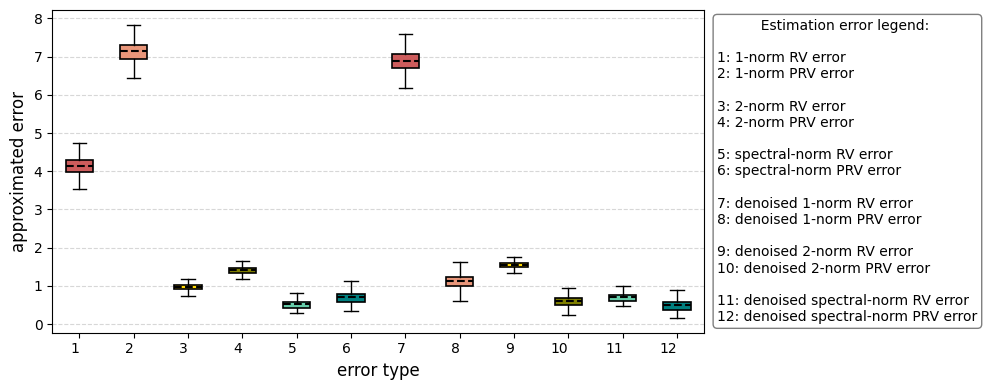

boxplot of estimation errors of the QV (means, no medians, no outliers)
ok


In [15]:
#plot for thesis

#boxplots of the errors

data=[nuclear_estimation_error_rv_monte_carlo, nuclear_estimation_error_prv_monte_carlo,
      frobenius_estimation_error_rv_monte_carlo, frobenius_estimation_error_prv_monte_carlo,
      spectral_estimation_error_rv_monte_carlo, spectral_estimation_error_prv_monte_carlo,
      only_factors_nuclear_estimation_error_rv_monte_carlo, only_factors_nuclear_estimation_error_prv_monte_carlo,
      only_factors_frobenius_estimation_error_rv_monte_carlo, only_factors_frobenius_estimation_error_prv_monte_carlo,
      only_factors_spectral_estimation_error_rv_monte_carlo, only_factors_spectral_estimation_error_prv_monte_carlo]

labels_errors=["1-norm rv error", "1-norm prv error",
        "2-norm rv error", "2-norm prv error",
        "spectral-norm rv error", "spectral-norm prv error",
        "denoised-1-norm rv error", "denoised-1-norm prv error",
        "denoised-2-norm rv error", "denoised-2-norm prv error",
        "denoised-spectral-norm rv error", "denoised-spectral-norm prv error"]

labels=range(1,13)

colors=["indianred","darksalmon","gold", "olive","mediumaquamarine", "teal",
        "indianred","darksalmon","gold", "olive","mediumaquamarine", "teal"]

fig, ax = plt.subplots(figsize=(10,4))# plt.figure(figsize=(10, 4))

# create boxplot
box =ax.boxplot(
    data,
    patch_artist=True, #colors for boxes
    notch=False, #no notches
    showmeans=True, #means
    meanline=True, #as lines
    showfliers=False #no outliers: then you need False
)

#apply colors
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_edgecolor('black')
    patch.set_linewidth(1.2)

#means
for mean in box['means']:
    mean.set(color='black', linewidth=1.5)

#no medians
for median in box['medians']:
    median.set_visible(False)
    #median.set(color='blue', linewidth=1.5)

# x-axis
ax.set_xticks(
    ticks=range(1, len(data)+1),
    labels=labels,
    rotation=0,
    ha='right' #end of labels at the tick
)


ax.grid(axis='y', linestyle='--', alpha=0.5) #alpha for transparency
ax.set_ylabel("approximated error", fontsize=12)
ax.set_xlabel("error type", fontsize=12)

#textbox as legend to the right

string="""          Estimation error legend:\n
1: 1-norm RV error\n2: 1-norm PRV error\n
3: 2-norm RV error\n4: 2-norm PRV error\n
5: spectral-norm RV error\n6: spectral-norm PRV error\n
7: denoised 1-norm RV error\n8: denoised 1-norm PRV error\n
9: denoised 2-norm RV error\n10: denoised 2-norm PRV error\n
11: denoised spectral-norm RV error\n12: denoised spectral-norm PRV error"""

ax.text(1.02, 0.5, string,       #(x,y) position and text
         transform=ax.transAxes, # position relative to axis not as data points
         fontsize=10, #size of text
         verticalalignment='center', #position (x,y) is center of box
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.5)) 
        #properties of box around legend, alpha=transparency of lines


plt.tight_layout()

plt.savefig("three_factors_error_boxplot.png", dpi=300, bbox_inches="tight")
#high resolution dpi, cut of edge bbox

plt.show()
plt.close()

print("boxplot of estimation errors of the QV (means, no medians, no outliers)")

print("ok")

In [16]:
#tests